<a href="https://colab.research.google.com/github/elsakhalil1968-lgtm/Rudolph-Rodriguez-Quamina/blob/main/Yelp_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Case Study: Yelp Restaurant Recommendation System
Context

Yelp was founded in 2004 to help people find great local businesses. Today, the website and their mobile application publish crowd-sourced reviews about local businesses as well as certain metadata about them that can help in customer's decision-making process. Yelp uses automated software to recommend the most helpful and reliable reviews for the Yelp community from such a large and diverse dataset.

The Yelp dataset is a large collection of user reviews, business metadata, business check-ins, users' social network data, user tips for businesses across 10 cities spread across 4 countries. The original dataset is very huge with ~ 11GB of data. In this case study, we will only use a subset of data due to the hardware limitations.
Objective

In this case study, we will build four types of recommendation systems:

    Knowledge/Rank Based recommendation system
    Similarity-Based Collaborative filtering
    Matrix Factorization Based Collaborative Filtering
    Clustering based recommendation system

Dataset

Out of many attributes available in the yelp_reviews data, we will only use the following four attributes:

    business_id
    business_name
    stars
    user_id

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use Google Colab for this case study.

Let's start by mounting the Google drive on Colab.


In [ ]:
!pip uninstall numpy -y

In [2]:
!pip install numpy==1.26.0

  Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.0 which is incom

In [1]:
#Mounting the Drive
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive")

Mounted at /content/drive


In [2]:
# Used to ignore the warning given as output of the code
import warnings
warnings.filterwarnings('ignore')

# Basic libraries of python for numeric and dataframe computations
import numpy as np, pandas as pd

# Basic library for data visualization
import matplotlib.pyplot as plt

# Slightly advanced library for data visualization
import seaborn as sns

# A dictionary output that does not raise a key error
from collections import defaultdict

# A performance metrics in sklearn
from sklearn.metrics import mean_squared_error


In [3]:
# Importing the dataset
yelp_review = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/yelp_reviews.csv', usecols = ['user_id', 'business_id', 'business_name', 'stars'], engine='python', on_bad_lines='skip')

# Dropping the "business_name" column
data = yelp_review.drop("business_name", axis = 1)

In [19]:
!pip install surprise

  Using cached surprise-0.1-py2.py3-none-any.whl.metadata (327 bytes)
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached surprise-0.1-py2.py3-none-any.whl (1.8 kB)
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554982 sha256=f9a6e94651abb7ca5092da7be650e242ee5051ff7f54185d1ac4c601d3a692b9
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229907 entries, 0 to 229906
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   business_id  229907 non-null  object
 1   stars        229907 non-null  int64 
 2   user_id      229907 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.3+ MB


In [7]:
data.head()

,business_id,stars,user_id
0,9yKzy9PApeiPPOUJEtnvkg,5,rLtl8ZkDX5vH5nAx9C3q5Q
1,ZRJwVLyzEJq1VAihDhYiow,5,0a2KyEL0d3Yb1V6aivbIuQ
2,6oRAC4uyJCsJl1X0WZpVSA,4,0hT2KtfLiobPvh6cDC8JQg
3,_1QQZuf4zZOyFCvXc0o6Vg,5,uZetl9T0NcROGOyFfughhg
4,6ozycU1RpktNG2-1BroVtw,5,vYmM4KTsC8ZfQBg-j5MWkw


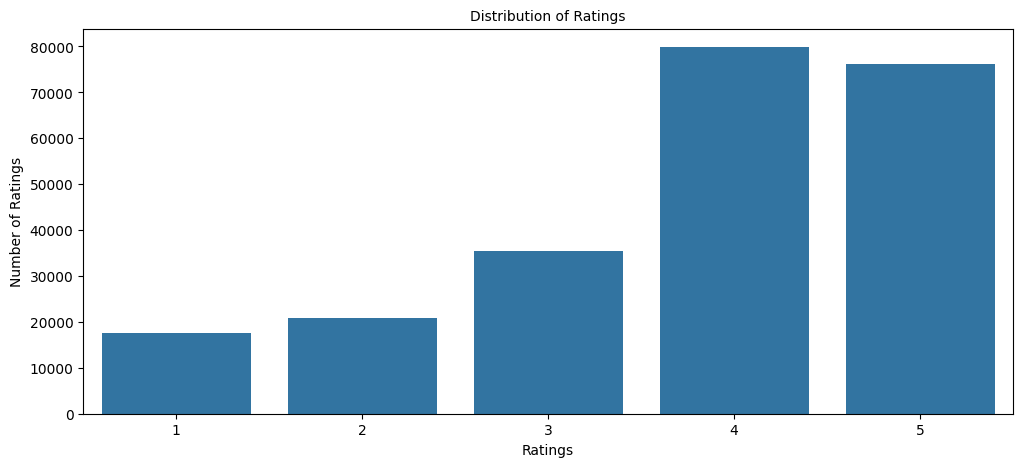

In [6]:
#Describe the Distribugtion of ratings
plt.figure(figsize= (12, 5))

ax = sns.countplot(x = "stars", data = data)
plt.tick_params(labelsize = 10)
plt.title("Distribution of Ratings", fontsize = 10)

#Set the xlabel of the plot
plt.xlabel("Ratings", fontsize = 10)

#Set the ylabel of the plot
plt.ylabel("Number of Ratings", fontsize = 10)

#Display the plot
plt.show()

THe data is highly skewed towards ratings 4 and 5 rating 5 is the second highest in the count and nearly the same number of 4 rating count.
we can see very few people gave ratings between 1 and 3

In [8]:
#What is the total number of unique users and unique restaurants?

In [9]:
data['user_id'].nunique()

45981

In [10]:
#Number of unique restaurants
data['business_id'].nunique()

11537

There are 24,104 users. There are 9882 unique businesses.

There are only 70,003 data sets but there is a potential of 24,104 * 9882 ratings


In [11]:
data.groupby(['user_id', 'business_id']).count()['stars'].sum()

229907

This implies that there is only one interaction between a pair of restaurants and a user


Which restaurants is the most reviewed restaurant in the data set?


In [12]:
data['business_id'].value_counts()

,count
business_id,
hW0Ne_HTHEAgGF1rAdmR-g,844
VVeogjZya58oiTxK7qUjAQ,794
JokKtdXU7zXHcr20Lrk29A,731
ntN85eu27C04nwyPa8IHtw,679
EWMwV5V9BxNs_U6nNVMeqw,645
...,...
-NbEHP2GHFNb5PnmJnd4qQ,3
QICgwHWhXIbihfcMKtws8g,3
sAwxt4I4gTiL-08nyarJbg,3


hW0Ne_HTHEAgGF1rAdmR-g is the most famous with 260 times. But there is a possibility of more interactions since we have 24,0000 unique users in the data set. So for those remaining people we can build a recommendation system for the rest.

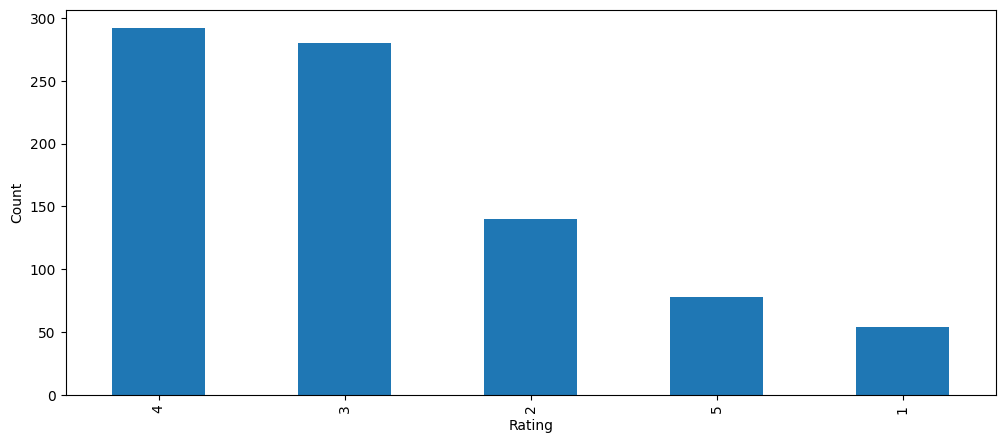

In [13]:
#Plotting the distribution of ratings for 260 interactions with given business _id
plt.figure(figsize= (12, 5))

data[data['business_id'] == 'hW0Ne_HTHEAgGF1rAdmR-g']['stars'].value_counts().plot(kind = 'bar')

plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [14]:
data['user_id'].value_counts()

,count
user_id,
fczQCSmaWF78toLEmb0Zsw,588
90a6z--_CUrl84aCzZyPsg,506
0CMz8YaO3f8xu4KqQgKb9Q,473
4ozupHULqGyO42s3zNUzOQ,442
joIzw_aUiNvBTuGoytrH7g,392
...,...
Oh9OOyDSGf4eNWGiNazh8g,1
Np9IEqnLmhRB2T5jumPTGw,1
g0-ejhzvo0ELNp04cUKWDg,1


In [15]:
#Get the column containing the users
users = data.user_id

ratings_count = dict()

for user in users:
  #If we already have the user, just add 1 to their rating count
  if user in ratings_count:
    ratings_count[user]+= 1
   #Otherwise, set their rating count to 1
  else:
      ratings_count[user] = 1


In [16]:
RATINGS_CUTOFF = 100

remove_users = []
for user, num_ratings in ratings_count.items():
  if num_ratings < RATINGS_CUTOFF:
    remove_users.append(user)
df_final = data.loc [ ~ data.user_id.isin(remove_users)]

Model 1: Building Rank-Based Recommendation System

Rank-based recommendation system provides recommendations based on the most popular items. This kind of recommendation system is useful when we have cold start problems. Cold start refers to the issue when we get a new user into the system and the machine is not able to recommend a restaurant to the new user, as the user did not have any historical interactions in the dataset. In those cases, we can use a rank-based recommendation system to recommend a restaurant to the new user.

To build the rank-based recommendation system, we take the average of all the ratings provided to each restaurant and then rank them based on their average rating.



In [17]:
#Calculating average ratings
average_rating = data.groupby('business_id')['stars'].mean()

#Calculating the count of ratings
count_rating = data.groupby('business_id')['stars'].count()
#Making a dataframe with the count and average of ratings
final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})

In [18]:
final_rating.head()


,avg_rating,rating_count
business_id,,
--5jkZ3-nUPZxUvtcbr8Uw,4.545455,11
--BlvDO_RG2yElKu9XA1_g,4.162162,37
-0D_CYhlD2ILkmLR0pBmnA,4.000000,5
-0QBrNvhrPQCaeo7mTo0zQ,4.333333,3
-0bUDim5OGuv8R0Qqq6J4A,2.333333,6


Lets create a function to find the top n restaurant for a recommendationb ased on the average ratings of the restaurant. We can also add a threshold for a minimum number of visits for a restaurant to be considered for recommendation


In [20]:
def top_n_restaurant(data, n, min_interaction = 100):

  # Finding restaurants with minimum number of interactions
  recommendation = data[data['rating_count'] > min_interaction]

  #Sorting values with respect to average rating
  recommendation = recommendation.sort_values(by = 'avg_rating', ascending = False)

  return recommendation.index[:n]

We can use this function with different n's and minimum interactions to get restaurants to recommend.


In [21]:
list(top_n_restaurant(final_rating, 5, 50))

['8HQ8clouLGgee99KkR4vXA',
 'CKjcewWeWvdJ7TzOQbZOIw',
 '97Z7j4vH0kfzL10AONi4uA',
 '_TekkyyFeX_8MBepPIxuTg',
 'L-uPZxooP_ziXCtRrWi8Pw']



Now, that we have seen how to apply the Rank-Based Recommendation System, let's apply the Collaborative Filtering Based Recommendation System.




Collaborative Filtering Based Recommendation System.

In this type of recommendation system, we do not need any information about the users or items. We only need user item interaction data to build a collaborative recommendation system. For example -

    Ratings provided by users. For example - ratings of books on goodread, movie ratings on imdb etc.
    Likes of users on different facebook posts, likes on youtube videos.
    Use/buying of a product by users. For example - buying different items on e-commerce sites.
    Reading of articles by readers on various blogs.

Types of Collaborative Filtering

    Similarity/Neighborhood-based

    User-User Similarity-Based
    Item-Item Similarity-based

    Model based

Building a baseline user-user similarity based recommendation system.

    Below we are building similarity-based recommendation systems using cosine similarity and using KNN to find similar users which are the nearest neighbor to the given user.
    We will be using a new library - surprise to build the remaining models, let's first import the necessary classes and functions from this library.



In [22]:
import surprise

In [23]:
# to compute the accuracy of models
from surprise import accuracy
# This class is used to parse a file containing ratings, dat ashould be in structure= user; item; rating
from surprise.reader import Reader
#Class for loading datasets
from surprise.dataset import Dataset
#For tuning model hyperparameter
from surprise.model_selection import GridSearchCV
#For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split
#For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic
#For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD
#For implementing k-fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering based recommendation
from surprise import CoClustering

In [24]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Returns precision and recall at k metrics for each user."""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant. When n_rec_k is 0,
        # Precision is undefined. We here set Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended. When n_rel is 0,
        # Recall is undefined. We here set Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    # Command to print the overall precision
    print('Precision: ', precision)

    # Command to print the overall recall
    print('Recall: ', recall)

    # Formula to compute the F-1 score
    print('F_1 score: ', round((2*precision * recall) / (precision + recall), 3))

In [25]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale = (0, 5))

# Loading the dataset
data = Dataset.load_from_df(df_final[['user_id', 'business_id', 'stars']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size = 0.2, random_state = 42)



    Now we are ready to build the first baseline similarity-based recommendation system using the cosine similarity.
    KNNBasic is an algorithm that is also associated with the surprise package, it is used to find the desired similar items among a given set of items.

    To compute precision and recall, a threshold of 3.5 and k value of 10 is taken for the recommended and relevant ratings.
    In the present case precision and recall both need to be optimized as the service provider would like to minimize both the losses discussed above. Hence, the correct performance measure is the F_1 score

In [26]:
#Declaring the simarility options
sim_options = {'name': 'cosine',
              'user_based': True}
# KNN Algorithm is used to find desired similar items
sim_user_user = KNNBasic(sim_options = sim_options, verbose = False, random_state = 1)

#Train the algorithm on the trainset, and predict ratings for the test set
sim_user_user.fit(trainset)

# Let us compute precision@k, recall@k, and f_q score with k = 10
precision_recall_at_k(sim_user_user)



RMSE: 1.0409
Precision:  0.773
Recall:  0.417
F_1 score:  0.542


In [27]:
# Predicting rating for a sample user with a restaurant that is not-visited by the user
sim_user_user.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "zp713qNhx8d9KCJJnrw1xA", verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: zp713qNhx8d9KCJJnrw1xA r_ui = None   est = 3.87   {'actual_k': 28, 'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='zp713qNhx8d9KCJJnrw1xA', r_ui=None, est=3.873369257511826, details={'actual_k': 28, 'was_impossible': False})

In [28]:
prediction_result = sim_user_user.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 3.77   {'actual_k': 16, 'was_impossible': False}


In [29]:
# Accessing attributes of the prediction_result object
print(f"User ID: {prediction_result.uid}")
print(f"Item ID: {prediction_result.iid}")
print(f"True rating (if available): {prediction_result.r_ui}")
print(f"Estimated rating: {prediction_result.est}")
print(f"Prediction details: {prediction_result.details}")


User ID: rLtl8ZkDX5vH5nAx9C3q5Q
Item ID: 9yKzy9PApeiPPOUJEtnvkg
True rating (if available): 5
Estimated rating: 3.7675091038953616
Prediction details: {'actual_k': 16, 'was_impossible': False}


In [30]:
param_grid = {'k': [20, 30, 40], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [True]}
              }
gs = GridSearchCV(KNNBasic, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

1.0163434202445285
{'k': 40, 'min_k': 6, 'sim_options': {'name': 'cosine', 'user_based': True}}




Once the grid search is complete, we can get the optimal values for each of those hyperparameters as shown above.

Now let's build the final model by using tuned values of the hyperparameters which we received by using grid search cross-validation.


In [31]:
# Here 0 is the internal id of the above user
# Retrieve the best parameters from the grid search
best_params = gs.best_params['rmse']

# Instantiate a new KNNBasic model with the best parameters
sim_user_user_optimized = KNNBasic(k=best_params['k'], min_k=best_params['min_k'], sim_options=best_params['sim_options'], verbose=False)

# Train the optimized model on the entire dataset (or trainset, depending on the use case)
sim_user_user_optimized.fit(trainset)

# Now get the neighbors using the optimized model
sim_user_user_optimized.get_neighbors(0, 5)

[18, 52, 79, 97, 103]

In [32]:
sim_option = {'name': 'cosine',
              'user_based': True}
sim_user_user_optimized = KNNBasic(sim_options = sim_options, k = 40, min_k = 6, random_state = 1, verbose = False)

sim_user_user_optimized.fit(trainset)

precision_recall_at_k(sim_user_user_optimized)


RMSE: 1.0060
Precision:  0.762
Recall:  0.413
F_1 score:  0.536


In [33]:
sim_user_user_optimized.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 3.77   {'actual_k': 16, 'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=3.7675091038953616, details={'actual_k': 16, 'was_impossible': False})

In [34]:
sim_user_user_optimized.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "zp713qNhx8d9KCJJnrw1xA", verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: zp713qNhx8d9KCJJnrw1xA r_ui = None   est = 3.87   {'actual_k': 28, 'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='zp713qNhx8d9KCJJnrw1xA', r_ui=None, est=3.873369257511826, details={'actual_k': 28, 'was_impossible': False})

In [35]:
sim_user_user_optimized.get_neighbors(0, 5)

[18, 52, 79, 97, 103]

In [36]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended restaurant ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot_table(index = 'user_id', columns = 'business_id', values = 'stars')

    # Extracting those restaurant ids which the user_id has not visited yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the restaurant ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non visited restaurant ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    # Returing top n highest predicted rating restaurants for this user
    return recommendations[:top_n]

In [37]:
#Making top 5 recommendations for user_id ""

In [38]:
recommendations = get_recommendations(df_final, "rLtl8ZkDX5vH5nAx9C3q5Q", 5, sim_user_user)

In [39]:
pd.DataFrame(recommendations, columns = ['business_id', 'predicted_ratings'])

,business_id,predicted_ratings
0,--5jkZ3-nUPZxUvtcbr8Uw,5
1,-7XuLxfYwZ9x72mEKXdv0A,5
2,-A82xEVAjOYZtDdRQw1FQw,5
3,-CZ78c-H3tTxpP-uQ09CWw,5
4,-J0jhpG0rv4saq9OMh8gXw,5


In [40]:
def ranking_products(recommendations, final_rating):
  #Sort the products based on ratings count
  ranked_products = final_rating.loc[[items[0] for items in recommendations ]].sort_values('rating_count', ascending = False)[['rating_count']].reset_index()

  #Merge with the recommended businesses to get predicted ratings
  ranked_products = ranked_products.merge(pd.DataFrame(recommendations, columns = ['business_id', 'predicted_ratings']), on = 'business_id', how = 'inner')

  #Rank the business based on corrected ratings
  ranked_products['corrected_ratings'] = ranked_products['predicted_ratings'] - 1/ np.sqrt(ranked_products['rating_count'])
  # Sort the businesses based on corrected ratings
  ranked_products = ranked_products.sort_values('corrected_ratings', ascending = False)

  return ranked_products

In [41]:
def ranking_products(recommendations, final_rating):
  #Sort the products based on ratings count
  ranked_products = final_rating.loc[[items[0] for items in recommendations ]].sort_values('rating_count', ascending = False)[['rating_count']].reset_index()

  #Merge with the recommended businesses to get predicted ratings
  ranked_products = ranked_products.merge(pd.DataFrame(recommendations, columns = ['business_id', 'predicted_ratings']), on = 'business_id', how = 'inner')

  #Rank the business based on corrected ratings
  ranked_products['corrected_ratings'] = ranked_products['predicted_ratings'] - 1/ np.sqrt(ranked_products['rating_count'])
  # Sort the businesses based on corrected ratings
  ranked_products = ranked_products.sort_values('corrected_ratings', ascending = False)

  return ranked_products

In [42]:
# Applying the ranking products function and sorting it based on corrected ratings
ranking_products(recommendations, final_rating)

,business_id,rating_count,predicted_ratings,corrected_ratings
0,--5jkZ3-nUPZxUvtcbr8Uw,11,5,4.698489
1,-J0jhpG0rv4saq9OMh8gXw,6,5,4.591752
2,-7XuLxfYwZ9x72mEKXdv0A,5,5,4.552786
3,-A82xEVAjOYZtDdRQw1FQw,5,5,4.552786
4,-CZ78c-H3tTxpP-uQ09CWw,3,5,4.422650




Note: In the above-corrected rating formula, we can add the quantity 1 / np.sqrt(n) instead of subtracting it to get more optimistic predictions. But here we are subtracting this quantity, as there are some products with ratings 5 and we can't have a rating more than 5 for a product.



In [43]:
#Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': False}
#KNN algorithm is used to find desired similar items
sim_item_item = KNNBasic(sim_options = sim_options, random_state = 1, verbose = False)

#Train the algorithm on the trainset, and predict ratings
sim_item_item.fit(trainset)

#Let us compute precision@k, recall@K, and f-1 score with k
precision_recall_at_k(sim_item_item)

RMSE: 1.0218
Precision:  0.663
Recall:  0.344
F_1 score:  0.453


In [45]:
sim_item_item.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 3.48   {'actual_k': 40, 'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=3.475, details={'actual_k': 40, 'was_impossible': False})

In [44]:
#Setting up parameter grid to tune the hyperparameters

param_grid = {'k': [10,20,30], 'min_k': [3, 6, 9],
'sim_options': {'name': ['msd', 'cosine'],
                'user_based': [False]}
             }
gs = GridSearchCV(KNNBasic, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

#Fitting the model on the data
gs.fit(data)
print(gs.best_score['rmse'])

#Print the combination of parameters that give best RMSE score
print(gs.best_params['rmse'])


1.0086249037326314
{'k': 30, 'min_k': 9, 'sim_options': {'name': 'msd', 'user_based': False}}


In [46]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options = {'name': 'msd',
               'user_based': False}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_item_item_optimized = KNNBasic(sim_options = sim_options, k = 30, min_k = 9, random_state = 1, verbose = False)

# Training the algorithm on the trainset
sim_item_item_optimized.fit(trainset)

# Let us compute precision@k and recall@k also with k = 10
precision_recall_at_k(sim_item_item_optimized)

RMSE: 0.9986
Precision:  0.708
Recall:  0.375
F_1 score:  0.49


In [47]:
sim_item_item_optimized.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 4.90   {'actual_k': 30, 'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=4.896024464831805, details={'actual_k': 30, 'was_impossible': False})

In [48]:
sim_item_item_optimized.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "zp713qNhx8d9KCJJnrw1xA", verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: zp713qNhx8d9KCJJnrw1xA r_ui = None   est = 3.71   {'actual_k': 30, 'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='zp713qNhx8d9KCJJnrw1xA', r_ui=None, est=3.705302758867788, details={'actual_k': 30, 'was_impossible': False})

In [49]:
sim_item_item_optimized.get_neighbors(0, k = 5)

[21, 27, 35, 51, 57]

In [50]:
 #Making top 5 recommendations for user_id rLtl8ZkDX5vH5nAx9C3q5Q with similarity-based recommendation engine
recommendations = get_recommendations(df_final, "rLtl8ZkDX5vH5nAx9C3q5Q", 5, sim_item_item_optimized)


In [51]:
# Building the dataframe for above recommendations with columns "business_id" and "predicted_ratings"
pd.DataFrame(recommendations, columns = ['business_id', 'predicted_ratings'])

,business_id,predicted_ratings
0,5Q49MxuWJgXS649i7i2Iow,4.416667
1,SmY_Xw31b2xyzsKbimQiHQ,4.346154
2,N6ff0yyo9Cv_7XPz-YDoow,4.308696
3,UmFnmIoLCRe1ywY0bzpRrQ,4.307692
4,p204PQg45gECcYwxCAK1wA,4.307692


In [52]:
# Applying the ranking_products function and sorting it based on corrected ratings
ranking_products(recommendations, final_rating)

,business_id,rating_count,predicted_ratings,corrected_ratings
1,5Q49MxuWJgXS649i7i2Iow,10,4.416667,4.100439
0,SmY_Xw31b2xyzsKbimQiHQ,15,4.346154,4.087955
2,N6ff0yyo9Cv_7XPz-YDoow,7,4.308696,3.930731
3,UmFnmIoLCRe1ywY0bzpRrQ,4,4.307692,3.807692
4,p204PQg45gECcYwxCAK1wA,3,4.307692,3.730342



Model 4: Building Model Based Collaborative Filtering Recommendation System - Matrix Factorization

Model-based Collaborative Filtering is a personalized recommendation system, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use latent features to find recommendations for each user.
Singular Value Decomposition (SVD)

SVD is used to compute the latent features from the user-item interaction matrix. But SVD does not work when values are missing in the user-item interaction matrix.
Building a baseline matrix factorization recommendation system

In [53]:
#Using SVD Matrix Factorization

svd = SVD(random_state = 1)

# Training the algorithm on the trainset
svd.fit(trainset)

#Let us compute precision@K and recall@K with k = 10
precision_recall_at_k(svd)

RMSE: 0.9630
Precision:  0.77
Recall:  0.383
F_1 score:  0.512


In [54]:
# Making the prediction
svd.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 4.16   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=4.155179595069889, details={'was_impossible': False})

In [55]:
# Making prediction using the svd model
svd.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "zp713qNhx8d9KCJJnrw1xA", verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: zp713qNhx8d9KCJJnrw1xA r_ui = None   est = 4.09   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='zp713qNhx8d9KCJJnrw1xA', r_ui=None, est=4.09204353877637, details={'was_impossible': False})

In [56]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01],
              'reg_all': [0.2, 0.4, 0.6]}

# Performing 3-fold gridsearch cross validation
gs = GridSearchCV(SVD, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

# Fitting the model on the data
gs.fit(data)

# Print the best RMSE score
print(gs.best_score['rmse'])

# Print the combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

0.957325380209617
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


In [57]:
# Building the optimized SVD model using optimal hyperparameter search
svd_optimized = SVD(n_epochs = 20, lr_all = 0.01, reg_all = 0.2, random_state = 1)

# Training the algorithm on the trainset
svd_optimized = svd_optimized.fit(trainset)

# Let us compute precision@k and recall@k also with k = 10
precision_recall_at_k(svd_optimized)

RMSE: 0.9507
Precision:  0.79
Recall:  0.402
F_1 score:  0.533


In [58]:
# Using svd_algo_optimized model to recommend for userId "rLtl8ZkDX5vH5nAx9C3q5Q" and business_Id 9yKzy9PApeiPPOUJEtnvkg
svd_optimized.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 3.91   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=3.9075441937737696, details={'was_impossible': False})

In [59]:
# Getting top 5 recommendations for user_id rLtl8ZkDX5vH5nAx9C3q5Q using "svd_optimized" algorithm
svd_recommendations = get_recommendations(df_final, "rLtl8ZkDX5vH5nAx9C3q5Q", 5, svd_optimized)

In [60]:
pd.DataFrame(svd_recommendations, columns = ['business_id', 'predicted_ratings'])

,business_id,predicted_ratings
0,X3icXUyW9vS4UXY6V_MR4w,4.764319
1,GwSdGrvaXi4BdXNSWKn-EA,4.645138
2,97Z7j4vH0kfzL10AONi4uA,4.637496
3,4SviSw8uRF0ddj_HxUVnuA,4.623874
4,XRBTHOXaJK_AJ2wy5mX_1A,4.622570


In [61]:
# Ranking products based on above recommendations
ranking_products(svd_recommendations, final_rating)

,business_id,rating_count,predicted_ratings,corrected_ratings
1,X3icXUyW9vS4UXY6V_MR4w,79,4.764319,4.651811
0,GwSdGrvaXi4BdXNSWKn-EA,153,4.645138,4.564293
2,97Z7j4vH0kfzL10AONi4uA,78,4.637496,4.524268
3,XRBTHOXaJK_AJ2wy5mX_1A,26,4.622570,4.426454
4,4SviSw8uRF0ddj_HxUVnuA,10,4.623874,4.307647


In [62]:
# Using Co-Clustering algorithm
clust_baseline = CoClustering(random_state = 1)

# Training the algorithm on the train set
clust_baseline.fit(trainset)

# Let us compute precision@k and recall@k with k = 10
precision_recall_at_k(clust_baseline)

RMSE: 1.0378
Precision:  0.765
Recall:  0.403
F_1 score:  0.528


In [63]:
# Making prediction for user_id 4 and business_id 9483
clust_baseline.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 3.97   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=3.966289107885623, details={'was_impossible': False})

In [64]:
# Making prediction for userid 4 and business_id 9980
clust_baseline.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "zp713qNhx8d9KCJJnrw1xA", verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: zp713qNhx8d9KCJJnrw1xA r_ui = None   est = 3.70   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='zp713qNhx8d9KCJJnrw1xA', r_ui=None, est=3.7039820276856474, details={'was_impossible': False})

In [65]:
# Set the parameter space to tune
param_grid = {'n_cltr_u': [3, 4, 5, 6], 'n_cltr_i': [3, 4, 5, 6], 'n_epochs': [30, 40, 50]}

# Performing 3-fold gridsearch cross validation
gs = GridSearchCV(CoClustering, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

# Fitting data
gs.fit(data)

# Print the best RMSE score
print(gs.best_score['rmse'])

# Print the combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

1.0483598458254877
{'n_cltr_u': 3, 'n_cltr_i': 3, 'n_epochs': 30}


In [66]:
# Using tuned Coclustering algorithm
clust_tuned = CoClustering(n_cltr_u = 3,n_cltr_i = 3, n_epochs = 40, random_state = 1)

# Training the algorithm on the train set
clust_tuned.fit(trainset)

# Let us compute precision@k and recall@k with k = 10
precision_recall_at_k(clust_tuned)


RMSE: 1.0373
Precision:  0.764
Recall:  0.404
F_1 score:  0.529


In [67]:
# Making prediction for user_id 4 and business_id 9483
clust_tuned.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "9yKzy9PApeiPPOUJEtnvkg", r_ui = 5, verbose = True)


user: rLtl8ZkDX5vH5nAx9C3q5Q item: 9yKzy9PApeiPPOUJEtnvkg r_ui = 5.00   est = 3.96   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='9yKzy9PApeiPPOUJEtnvkg', r_ui=5, est=3.9644335253991674, details={'was_impossible': False})

In [68]:
# Making prediction for userid 4 and business_id 9980
clust_tuned.predict("rLtl8ZkDX5vH5nAx9C3q5Q", "zp713qNhx8d9KCJJnrw1xA", verbose = True)

user: rLtl8ZkDX5vH5nAx9C3q5Q item: zp713qNhx8d9KCJJnrw1xA r_ui = None   est = 3.73   {'was_impossible': False}


Prediction(uid='rLtl8ZkDX5vH5nAx9C3q5Q', iid='zp713qNhx8d9KCJJnrw1xA', r_ui=None, est=3.730191262361615, details={'was_impossible': False})

In [69]:
# Getting top 5 recommendations for user_id 4 using "Co-clustering based optimized" algorithm
clustering_recommendations = get_recommendations(df_final, "rLtl8ZkDX5vH5nAx9C3q5Q", 5, clust_tuned)

In [70]:
clustering_recommendations = get_recommendations(df_final, "rLtl8ZkDX5vH5nAx9C3q5Q", 5, clust_tuned)
pd.DataFrame(clustering_recommendations, columns = ['business_id', 'predicted_ratings'])

,business_id,predicted_ratings
0,--5jkZ3-nUPZxUvtcbr8Uw,5
1,-7XuLxfYwZ9x72mEKXdv0A,5
2,-CZ78c-H3tTxpP-uQ09CWw,5
3,-JYWpdJfMkqCTA_7fyz6Cw,5
4,-Mf4I8Jr_Vly37Z3Mgf0zQ,5


In [71]:
ranking_products(clustering_recommendations, final_rating)

,business_id,rating_count,predicted_ratings,corrected_ratings
0,--5jkZ3-nUPZxUvtcbr8Uw,11,5,4.698489
1,-Mf4I8Jr_Vly37Z3Mgf0zQ,10,5,4.683772
2,-7XuLxfYwZ9x72mEKXdv0A,5,5,4.552786
3,-JYWpdJfMkqCTA_7fyz6Cw,4,5,4.500000
4,-CZ78c-H3tTxpP-uQ09CWw,3,5,4.422650


In [73]:
ranking_products(clustering_recommendations, final_rating)

,business_id,rating_count,predicted_ratings,corrected_ratings
0,--5jkZ3-nUPZxUvtcbr8Uw,11,5,4.698489
1,-Mf4I8Jr_Vly37Z3Mgf0zQ,10,5,4.683772
2,-7XuLxfYwZ9x72mEKXdv0A,5,5,4.552786
3,-JYWpdJfMkqCTA_7fyz6Cw,4,5,4.500000
4,-CZ78c-H3tTxpP-uQ09CWw,3,5,4.422650


In [72]:
# Ranking restaurants based on above recommendations
ranking_products(clustering_recommendations, final_rating)


,business_id,rating_count,predicted_ratings,corrected_ratings
0,--5jkZ3-nUPZxUvtcbr8Uw,11,5,4.698489
1,-Mf4I8Jr_Vly37Z3Mgf0zQ,10,5,4.683772
2,-7XuLxfYwZ9x72mEKXdv0A,5,5,4.552786
3,-JYWpdJfMkqCTA_7fyz6Cw,4,5,4.500000
4,-CZ78c-H3tTxpP-uQ09CWw,3,5,4.422650
